# TITLE

### subtitle

image

Intro

In [77]:
#imports

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix


In [2]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

## Exploratory Data Analysis

Some exlaination

### Raw data

add where data coming from

In [3]:
circuits = pd.read_csv("../data/circuits.csv")
constructor_results = pd.read_csv("../data/constructor_results.csv")
constructor_standings = pd.read_csv("../data/constructor_standings.csv")
constructors = pd.read_csv("../data/constructors.csv")
driver_standings = pd.read_csv("../data/driver_standings.csv")
drivers = pd.read_csv("../data/drivers.csv")
lap_times = pd.read_csv("../data/lap_times.csv")
pit_stops = pd.read_csv("../data/pit_stops.csv")
qualifying = pd.read_csv("../data/qualifying.csv")
races = pd.read_csv("../data/races.csv")
results = pd.read_csv("../data/results.csv")
seasons = pd.read_csv("../data/seasons.csv")
sprint_results = pd.read_csv("../data/sprint_results.csv")
status = pd.read_csv("../data/status.csv")

Explain this data how its split up and next steps

In [4]:
#remove 

tables = {
    "circuits": circuits,
    "constructor_results": constructor_results,
    "constructor_standings": constructor_standings,
    "constructors": constructors,
    "driver_standings": driver_standings,
    "drivers": drivers,
    "lap_times": lap_times,
    "pit_stops": pit_stops,
    "qualifying": qualifying,
    "races": races,
    "results": results,
    "seasons": seasons,
    "sprint_results": sprint_results,
    "status": status
}

table_summary = []

for name, table in tables.items():
    table_summary.append({
        "table_name": name,
        "columns": ", ".join(table.columns.tolist())
    })

table_summary_df = pd.DataFrame(table_summary)

table_summary_df

,table_name,columns
0,circuits,"circuitId, circuitRef, name, location, country, lat, lng, alt, url"
1,constructor_results,"constructorResultsId, raceId, constructorId, points, status"
2,constructor_standings,"constructorStandingsId, raceId, constructorId, points, position, positionText, wins"
3,constructors,"constructorId, constructorRef, name, nationality, url"
4,driver_standings,"driverStandingsId, raceId, driverId, points, position, positionText, wins"
5,drivers,"driverId, driverRef, number, code, forename, surname, dob, nationality, url"
6,lap_times,"raceId, driverId, lap, position, time, milliseconds"
7,pit_stops,"raceId, driverId, stop, lap, time, duration, milliseconds"
8,qualifying,"qualifyId, raceId, driverId, constructorId, number, position, q1, q2, q3"
9,races,"raceId, year, round, circuitId, name, date, time, url, fp1_date, fp1_time, fp2_date, fp2_time, fp3_date, fp3_time, quali_date, quali_time, sprint_date, sprint_time"


#### Raw Data summary

summary of the tables in this dataset, their shapes, missing values etc

In [5]:
summary = []

for name, table in tables.items():
    summary.append({
        "table": name,
        "rows": table.shape[0],
        "columns": table.shape[1],
        "missing_values": table.isna().sum().sum()
    })

table_summary = pd.DataFrame(summary)
table_summary

,table,rows,columns,missing_values
0,circuits,77,9,0
1,constructor_results,12625,5,0
2,constructor_standings,13391,7,0
3,constructors,212,5,0
4,driver_standings,34863,7,0
5,drivers,861,9,0
6,lap_times,589081,6,0
7,pit_stops,11371,7,0
8,qualifying,10494,9,68
9,races,1125,18,0


To get an idea of the podium finished lets visualize

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

#podium variable from raw results table
results_eda = results.copy()
results_eda["podium"] = results_eda["positionOrder"].apply(
    lambda x: "Podium" if x <= 3 else "Not Podium"
)

#count podium vs non-podium
podium_counts = results_eda["podium"].value_counts().reset_index()
podium_counts.columns = ["finish_type", "count"]

podium_counts

,finish_type,count
0,Not Podium,23362
1,Podium,3397


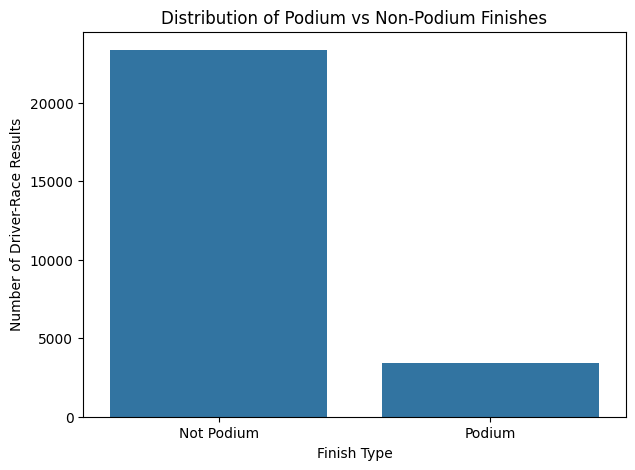

In [7]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=podium_counts,
    x="finish_type",
    y="count"
)

plt.title("Distribution of Podium vs Non-Podium Finishes")
plt.xlabel("Finish Type")
plt.ylabel("Number of Driver-Race Results")
plt.show()

### Merge dataset into one master dataset

In [8]:
df = results.copy()

df = df.merge(races, on="raceId", how="left", suffixes=("", "_race"))
df = df.merge(drivers, on="driverId", how="left", suffixes=("", "_driver"))
df = df.merge(constructors, on="constructorId", how="left", suffixes=("", "_constructor"))
df = df.merge(circuits, on="circuitId", how="left", suffixes=("", "_circuit"))
df = df.merge(status, on="statusId", how="left")


df = df.rename(columns={
    "name": "race_name",
    "url": "race_url",
    "time_race": "race_time",
    "name_constructor": "constructor_name",
    "nationality_constructor": "constructor_nationality",
    "url_constructor": "constructor_url",
    "name_circuit": "circuit_name",
    "url_circuit": "circuit_url",
    "location": "circuit_location",
    "country": "circuit_country"
})

df.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,year,round,circuitId,race_name,date,race_time,race_url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time,driverRef,number_driver,code,forename,surname,dob,nationality,url_driver,constructorRef,constructor_name,constructor_nationality,constructor_url,circuitRef,circuit_name,circuit_location,circuit_country,lat,lng,alt,circuit_url,status
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1,2008,1,1,Australian Grand Prix,2008-03-16,04:30:00,http://en.wikipedia.org/wiki/2008_Australian_Grand_Prix,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,http://en.wikipedia.org/wiki/Melbourne_Grand_Prix_Circuit,Finished
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1,2008,1,1,Australian Grand Prix,2008-03-16,04:30:00,http://en.wikipedia.org/wiki/2008_Australian_Grand_Prix,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N,heidfeld,\N,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,http://en.wikipedia.org/wiki/Melbourne_Grand_Prix_Circuit,Finished
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1,2008,1,1,Australian Grand Prix,2008-03-16,04:30:00,http://en.wikipedia.org/wiki/2008_Australian_Grand_Prix,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N,rosberg,6,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Prix_Engineering,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,http://en.wikipedia.org/wiki/Melbourne_Grand_Prix_Circuit,Finished
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1,2008,1,1,Australian Grand Prix,2008-03-16,04:30:00,http://en.wikipedia.org/wiki/2008_Australian_Grand_Prix,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N,alonso,14,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formula_One,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,http://en.wikipedia.org/wiki/Melbourne_Grand_Prix_Circuit,Finished
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1,2008,1,1,Australian Grand Prix,2008-03-16,04:30:00,http://en.wikipedia.org/wiki/2008_Australian_Grand_Prix,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N,kovalainen,\N,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,http://en.wikipedia.org/wiki/Melbourne_Grand_Prix_Circuit,Finished


#### Add Qualifying Data

In [9]:
new_qualifying = qualifying[[
    "raceId",
    "driverId",
    "constructorId",
    "position",
    "q1",
    "q2",
    "q3"
]].copy()

new_qualifying = new_qualifying.rename(columns={"position": "qualifying_position"})

df = df.merge(
    new_qualifying,
    on=["raceId", "driverId", "constructorId"],
    how="left"
)

#### Add Driver Standing Before Race

In [10]:
new_driver_standings = driver_standings[[
    "raceId",
    "driverId",
    "points",
    "position",
    "wins"
]].copy()

new_driver_standings = new_driver_standings.rename(columns={
    "points": "driver_points_after_race",
    "position": "driver_standing_after_race",
    "wins": "driver_wins_after_race"
})

df = df.merge(
    new_driver_standings,
    on=["raceId", "driverId"],
    how="left"
)

#### Add Constructor Standings

In [11]:
new_constructor_standings = constructor_standings[[
    "raceId",
    "constructorId",
    "points",
    "position",
    "wins"
]].copy()

new_constructor_standings = new_constructor_standings.rename(columns={
    "points": "constructor_points_after_race",
    "position": "constructor_standing_after_race",
    "wins": "constructor_wins_after_race"
})

df = df.merge(
    new_constructor_standings,
    on=["raceId", "constructorId"],
    how="left"
)

#### Add Constructor Race Results

In [12]:
new_constructor_results = constructor_results[[
    "raceId",
    "constructorId",
    "points"
]].copy()

new_constructor_results = new_constructor_results.rename(columns={
    "points": "constructor_points_race"
})

df = df.merge(
    new_constructor_results,
    on=["raceId", "constructorId"],
    how="left"
)

#### Add Pit Stop Data
- number of pit stops
- mean times
- total pit stop time for that race

In [13]:
pit_features = (
    pit_stops
    .groupby(["raceId", "driverId"])
    .agg(
        num_pit_stops=("stop", "count"),
        avg_pit_stop_ms=("milliseconds", "mean"),
        total_pit_stop_ms=("milliseconds", "sum")
    )
    .reset_index()
)

df = df.merge(
    pit_features,
    on=["raceId", "driverId"],
    how="left"
)

In [14]:
#fill in missing pit stop data
df["num_pit_stops"] = df["num_pit_stops"].fillna(0)

#### Add Lap Times
- avg lap time
- best lap time
- std of lap times

In [15]:
lap_features = (
    lap_times
    .groupby(["raceId", "driverId"])
    .agg(
        avg_lap_ms=("milliseconds", "mean"),
        best_lap_ms=("milliseconds", "min"),
        lap_time_std_ms=("milliseconds", "std")
    )
    .reset_index()
)

df = df.merge(
    lap_features,
    on=["raceId", "driverId"],
    how="left"
)

#### Add Sprint Results

In [16]:

new_sprint = sprint_results[[
    "raceId",
    "driverId",
    "constructorId",
    "grid",
    "positionOrder",
    "points"
]].copy()

new_sprint = new_sprint.rename(columns={
    "grid": "sprint_grid",
    "positionOrder": "sprint_positionOrder",
    "points": "sprint_points"
})

df = df.merge(
    new_sprint,
    on=["raceId", "driverId", "constructorId"],
    how="left"
)

### Checks

double check if Bahrain 2024 Grang Prix 

In [17]:
df.shape

(26759, 76)

In [18]:
#2024 Bahrain GP
races[
    (races["year"] == 2024) & (races["name"].str.contains("Bahrain", case=False, na=False))
]


,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
1101,1121,2024,1,3,Bahrain Grand Prix,2024-03-02,15:00:00,https://en.wikipedia.org/wiki/2024_Bahrain_Grand_Prix,2024-02-29,11:30:00,2024-02-29,15:00:00,2024-03-01,12:30:00,2024-03-01,16:00:00,\N,\N


In [19]:
bahrain_2024_race = races[
    (races["year"] == 2024) &
    (races["name"].str.contains("Bahrain", case=False, na=False))
]

bahrain_2024_id = bahrain_2024_race["raceId"].iloc[0]

bahrain_2024_id

np.int64(1121)

In [20]:
bahrain_2024_data = df[df["raceId"] == bahrain_2024_id].copy()

bahrain_2024_clean = bahrain_2024_data[[
    "raceId",
    "year",
    "round",
    "circuit_name",
    "date",
    "driverId",
    "forename",
    "surname",
    "constructorId",
    "constructor_name",
    "grid",
    "positionOrder",
    "positionText",
    "points",
    "status",
    "qualifying_position",
    "driver_points_after_race",
    "driver_standing_after_race",
    "constructor_points_after_race",
    "constructor_standing_after_race"
]].sort_values("positionOrder")

bahrain_2024_clean

,raceId,year,round,circuit_name,date,driverId,forename,surname,constructorId,constructor_name,grid,positionOrder,positionText,points,status,qualifying_position,driver_points_after_race,driver_standing_after_race,constructor_points_after_race,constructor_standing_after_race
26280,1121,2024,1,Bahrain International Circuit,2024-03-02,830,Max,Verstappen,9,Red Bull,1,1,1,26.0,Finished,1.0,26.0,1.0,44.0,1.0
26281,1121,2024,1,Bahrain International Circuit,2024-03-02,815,Sergio,Pérez,9,Red Bull,5,2,2,18.0,Finished,5.0,18.0,2.0,44.0,1.0
26282,1121,2024,1,Bahrain International Circuit,2024-03-02,832,Carlos,Sainz,6,Ferrari,4,3,3,15.0,Finished,4.0,15.0,3.0,27.0,2.0
26283,1121,2024,1,Bahrain International Circuit,2024-03-02,844,Charles,Leclerc,6,Ferrari,2,4,4,12.0,Finished,2.0,12.0,4.0,27.0,2.0
26284,1121,2024,1,Bahrain International Circuit,2024-03-02,847,George,Russell,131,Mercedes,3,5,5,10.0,Finished,3.0,10.0,5.0,16.0,3.0
26285,1121,2024,1,Bahrain International Circuit,2024-03-02,846,Lando,Norris,1,McLaren,7,6,6,8.0,Finished,7.0,8.0,6.0,12.0,4.0
26286,1121,2024,1,Bahrain International Circuit,2024-03-02,1,Lewis,Hamilton,131,Mercedes,9,7,7,6.0,Finished,9.0,6.0,7.0,16.0,3.0
26287,1121,2024,1,Bahrain International Circuit,2024-03-02,857,Oscar,Piastri,1,McLaren,8,8,8,4.0,Finished,8.0,4.0,8.0,12.0,4.0
26288,1121,2024,1,Bahrain International Circuit,2024-03-02,4,Fernando,Alonso,117,Aston Martin,6,9,9,2.0,Finished,6.0,2.0,9.0,3.0,5.0
26289,1121,2024,1,Bahrain International Circuit,2024-03-02,840,Lance,Stroll,117,Aston Martin,12,10,10,1.0,Finished,12.0,1.0,10.0,3.0,5.0


#### Save master set

In [21]:
import os

os.makedirs("../data/processed", exist_ok=True)

df.to_csv("../data/processed/f1_full_merged_dataset.csv", index=False)

## Before Race Data

Some variables in this dataset are only known during or after race, such as final position, points, pit stops, lap times, race status, fastest lap information, and race-level constructor points. These variables will not be used in the final pre-race prediction model because they would cause data leakage.

### Before race stadings

In [22]:
#driver 

df = df.sort_values(["driverId", "year", "round"])

df["driver_points_before_race"] = (
    df.groupby(["driverId", "year"])["driver_points_after_race"]
    .shift(1)
)

df["driver_standing_before_race"] = (
    df.groupby(["driverId", "year"])["driver_standing_after_race"]
    .shift(1)
)

df["driver_wins_before_race"] = (
    df.groupby(["driverId", "year"])["driver_wins_after_race"]
    .shift(1)
)

df["driver_standing_before_race"] = df["driver_standing_before_race"].fillna(99)

In [23]:
#contructor, corrected for 2 drivers in same race

constructor_race = (
    df[[
        "constructorId",
        "year",
        "round",
        "raceId",
        "constructor_points_after_race",
        "constructor_standing_after_race",
        "constructor_wins_after_race"
    ]]
    .drop_duplicates()
    .sort_values(["constructorId", "year", "round"])
)

constructor_race["constructor_points_before_race"] = (
    constructor_race.groupby(["constructorId", "year"])["constructor_points_after_race"]
    .shift(1)
)

constructor_race["constructor_standing_before_race"] = (
    constructor_race.groupby(["constructorId", "year"])["constructor_standing_after_race"]
    .shift(1)
)

constructor_race["constructor_wins_before_race"] = (
    constructor_race.groupby(["constructorId", "year"])["constructor_wins_after_race"]
    .shift(1)
)

constructor_race["constructor_points_before_race"] = constructor_race["constructor_points_before_race"].fillna(0)
constructor_race["constructor_wins_before_race"] = constructor_race["constructor_wins_before_race"].fillna(0)
constructor_race["constructor_standing_before_race"] = constructor_race["constructor_standing_before_race"].fillna(99)

df = df.drop(columns=[
    "constructor_points_before_race",
    "constructor_standing_before_race",
    "constructor_wins_before_race"
], errors="ignore")

df = df.merge(
    constructor_race[[
        "constructorId",
        "raceId",
        "constructor_points_before_race",
        "constructor_standing_before_race",
        "constructor_wins_before_race"
    ]],
    on=["constructorId", "raceId"],
    how="left"
)

In [24]:
#missing values from first race of each season

df["driver_points_before_race"] = df["driver_points_before_race"].fillna(0)
df["driver_wins_before_race"] = df["driver_wins_before_race"].fillna(0)

df["constructor_points_before_race"] = df["constructor_points_before_race"].fillna(0)
df["constructor_wins_before_race"] = df["constructor_wins_before_race"].fillna(0)


### Historical Performance

Limit to 5 previous races at same circuit 

In [25]:
# make sure data is sorted in true race order
df = df.sort_values(["year", "round", "raceId", "driverId"]).copy()

# make sure podium exists first
df["podium"] = (df["positionOrder"] <= 3).astype(int)

#### Driver Historical Performance, same circuit

In [26]:
driver_circuit_group = df.groupby(["driverId", "circuitId"], group_keys=False)

#avg lap time
df["driver_circuit_avg_finish_last5"] = (
    driver_circuit_group["positionOrder"]
    .apply(lambda x: x.shift(1).rolling(window=5, min_periods=1).mean())
)

#avg podium rate
df["driver_circuit_podium_rate_last5"] = (
    driver_circuit_group["podium"]
    .apply(lambda x: x.shift(1).rolling(window=5, min_periods=1).mean())
)

#avg points 
df["driver_circuit_avg_points_last5"] = (
    driver_circuit_group["points"]
    .apply(lambda x: x.shift(1).rolling(window=5, min_periods=1).mean())
)


### Driver Performance last 5 races, regardless of circuit

In [27]:
# driver recent form across all races, previous 5 races only
driver_group = df.groupby("driverId", group_keys=False)

df["driver_recent_avg_finish_last5"] = (
    driver_group["positionOrder"]
    .apply(lambda x: x.shift(1).rolling(window=5, min_periods=1).mean())
)

df["driver_recent_podium_rate_last5"] = (
    driver_group["podium"]
    .apply(lambda x: x.shift(1).rolling(window=5, min_periods=1).mean())
)

df["driver_recent_avg_points_last5"] = (
    driver_group["points"]
    .apply(lambda x: x.shift(1).rolling(window=5, min_periods=1).mean())
)

In [28]:
driver_history_cols = [
    "driver_circuit_avg_finish_last5",
    "driver_circuit_podium_rate_last5",
    "driver_circuit_avg_points_last5",
]

df[driver_history_cols] = df[driver_history_cols].fillna(0)

### Checks for Bahrain 2024 GP

In [29]:
bahrain_2024 = df[(df["year"] == 2024) & (df["round"] == 1)].copy()

bahrain_check_cols = [
    "raceId",
    "year",
    "round",
    "circuit_name",
    "date",
    "driverId",
    "forename",
    "surname",
    "constructorId",
    "constructor_name",
    "grid",
    "qualifying_position",
    
    # before-race season standings
    "driver_points_before_race",
    "driver_standing_before_race",
    "driver_wins_before_race",
    
    # driver same-circuit history
    "driver_circuit_avg_finish_last5",
    "driver_circuit_podium_rate_last5",
    "driver_circuit_avg_points_last5",
    
    # driver race history regardless of circuit
    "driver_recent_avg_finish_last5",
    "driver_recent_podium_rate_last5",
    "driver_recent_avg_points_last5",
    
    # outcome columns
    "positionOrder",
    "positionText",
    "points",
    "podium",
    "status"
]

bahrain_2024[bahrain_check_cols].sort_values("positionOrder")


,raceId,year,round,circuit_name,date,driverId,forename,surname,constructorId,constructor_name,grid,qualifying_position,driver_points_before_race,driver_standing_before_race,driver_wins_before_race,driver_circuit_avg_finish_last5,driver_circuit_podium_rate_last5,driver_circuit_avg_points_last5,driver_recent_avg_finish_last5,driver_recent_podium_rate_last5,driver_recent_avg_points_last5,positionOrder,positionText,points,podium,status
24838,1121,2024,1,Bahrain International Circuit,2024-03-02,830,Max,Verstappen,9,Red Bull,1,1.0,0.0,99.0,0.0,8.600000,0.6,12.4,1.0,1.0,25.2,1,1,26.0,1,Finished
23446,1121,2024,1,Bahrain International Circuit,2024-03-02,815,Sergio,Pérez,9,Red Bull,5,5.0,0.0,99.0,0.0,8.800000,0.4,10.6,7.0,0.2,10.2,2,2,18.0,1,Finished
25087,1121,2024,1,Bahrain International Circuit,2024-03-02,832,Carlos,Sainz,6,Ferrari,4,4.0,0.0,99.0,0.0,4.600000,0.2,11.2,7.4,0.2,8.6,3,3,15.0,1,Finished
25948,1121,2024,1,Bahrain International Circuit,2024-03-02,844,Charles,Leclerc,6,Ferrari,2,2.0,0.0,99.0,0.0,11.200000,0.2,7.0,9.4,0.6,10.2,4,4,12.0,0,Finished
26225,1121,2024,1,Bahrain International Circuit,2024-03-02,847,George,Russell,131,Mercedes,3,3.0,0.0,99.0,0.0,9.200000,0.0,4.2,7.4,0.2,7.4,5,5,10.0,0,Finished
26097,1121,2024,1,Bahrain International Circuit,2024-03-02,846,Lando,Norris,1,McLaren,7,7.0,0.0,99.0,0.0,10.000000,0.0,5.0,6.8,0.4,11.4,6,6,8.0,0,Finished
332,1121,2024,1,Bahrain International Circuit,2024-03-02,1,Lewis,Hamilton,131,Mercedes,9,9.0,0.0,99.0,0.0,2.200000,0.8,20.0,9.0,0.2,6.2,7,7,6.0,0,Finished
26675,1121,2024,1,Bahrain International Circuit,2024-03-02,857,Oscar,Piastri,1,McLaren,8,8.0,0.0,99.0,0.0,20.000000,0.0,0.0,11.0,0.0,2.8,8,8,4.0,0,Finished
1126,1121,2024,1,Bahrain International Circuit,2024-03-02,4,Fernando,Alonso,117,Aston Martin,6,6.0,0.0,99.0,0.0,10.400000,0.2,4.6,10.6,0.2,4.6,9,9,2.0,0,Finished
25558,1121,2024,1,Bahrain International Circuit,2024-03-02,840,Lance,Stroll,117,Aston Martin,12,12.0,0.0,99.0,0.0,10.000000,0.2,4.8,8.8,0.0,5.4,10,10,1.0,0,Finished


## Target Variable

In [30]:
df["podium"] = (df["positionOrder"] <= 3).astype(int)

df["podium_place"] = np.where(
    df["positionOrder"] <= 3,
    df["positionOrder"],
    np.nan
)

In [31]:
df["podium"].value_counts()
df["podium"].value_counts(normalize=True)

podium
0    0.873052
1    0.126948
Name: proportion, dtype: float64

In [32]:
df.to_csv("../data/processed/before_race_merged_dataset.csv", index=False)

## Create the modeling dataset

In [33]:
df = pd.read_csv("../data/processed/before_race_merged_dataset.csv", low_memory=False)

modeling_data = df[[
    
    #identifiers / labels, not predictors
    "raceId",
    "driverId",
    "forename",
    "surname",
    "constructorId",
    "constructor_name",
    "circuitId",
    "circuit_name",
    "year",
    "round",

    #pre race predictors
    "grid",
    "qualifying_position",

    "driver_points_before_race",
    "driver_standing_before_race",
    "driver_wins_before_race",

    "constructor_points_before_race",
    "constructor_standing_before_race",
    "constructor_wins_before_race",

    #driver circuit history
    "driver_circuit_avg_finish_last5",
    "driver_circuit_podium_rate_last5",
    "driver_circuit_avg_points_last5",

    #driver recent histry, regardless of circuit
    "driver_recent_avg_finish_last5",
    "driver_recent_podium_rate_last5",
    "driver_recent_avg_points_last5",
    

    #outcome columns, not predictors
    "positionOrder",
    "podium"
]].copy()

modeling_data.head()


,raceId,driverId,forename,surname,constructorId,constructor_name,circuitId,circuit_name,year,round,grid,qualifying_position,driver_points_before_race,driver_standing_before_race,driver_wins_before_race,constructor_points_before_race,constructor_standing_before_race,constructor_wins_before_race,driver_circuit_avg_finish_last5,driver_circuit_podium_rate_last5,driver_circuit_avg_points_last5,driver_recent_avg_finish_last5,driver_recent_podium_rate_last5,driver_recent_avg_points_last5,positionOrder,podium
0,833,579,Juan,Fangio,51,Alfa Romeo,9,Silverstone Circuit,1950,1,3,NaN,0.0,99.0,0.0,0.0,99.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,12,0
1,833,589,Louis,Chiron,105,Maserati,9,Silverstone Circuit,1950,1,11,NaN,0.0,99.0,0.0,0.0,99.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,18,0
2,833,619,Bob,Gerard,151,ERA,9,Silverstone Circuit,1950,1,13,NaN,0.0,99.0,0.0,0.0,99.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,6,0
3,833,627,Louis,Rosier,154,Talbot-Lago,9,Silverstone Circuit,1950,1,9,NaN,0.0,99.0,0.0,0.0,99.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,5,0
4,833,640,Toulo,de Graffenried,105,Maserati,9,Silverstone Circuit,1950,1,8,NaN,0.0,99.0,0.0,0.0,99.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,17,0


#### Handling missing data

In [34]:
modeling_data.isna().sum()

raceId                                  0
driverId                                0
forename                                0
surname                                 0
constructorId                           0
constructor_name                        0
circuitId                               0
circuit_name                            0
year                                    0
round                                   0
grid                                    0
qualifying_position                 16275
driver_points_before_race               0
driver_standing_before_race             0
driver_wins_before_race                 0
constructor_points_before_race          0
constructor_standing_before_race        0
constructor_wins_before_race            0
driver_circuit_avg_finish_last5         0
driver_circuit_podium_rate_last5        0
driver_circuit_avg_points_last5         0
driver_recent_avg_finish_last5        861
driver_recent_podium_rate_last5       861
driver_recent_avg_points_last5    

Drop rows with missing qualifying position data, this is a strong predictor, so remove them

ADD MORE ABOUT CORRECTING MISSING DATA

In [35]:
#drop rows missing qualifying position
modeling_data = modeling_data.dropna(subset=["qualifying_position"]).copy()

#fill missing recent driver history
modeling_data["driver_recent_avg_finish_last5"] = modeling_data["driver_recent_avg_finish_last5"].fillna(99)
modeling_data["driver_recent_podium_rate_last5"] = modeling_data["driver_recent_podium_rate_last5"].fillna(0)
modeling_data["driver_recent_avg_points_last5"] = modeling_data["driver_recent_avg_points_last5"].fillna(0)

#fill missing circuit history
modeling_data["driver_circuit_avg_finish_last5"] = modeling_data["driver_circuit_avg_finish_last5"].fillna(99)
modeling_data["driver_circuit_podium_rate_last5"] = modeling_data["driver_circuit_podium_rate_last5"].fillna(0)
modeling_data["driver_circuit_avg_points_last5"] = modeling_data["driver_circuit_avg_points_last5"].fillna(0)


In [36]:
#save modeling dataset
modeling_data.to_csv("../data/processed/f1_modeling_dataset.csv", index=False)

## Predictor Coorelation Plot

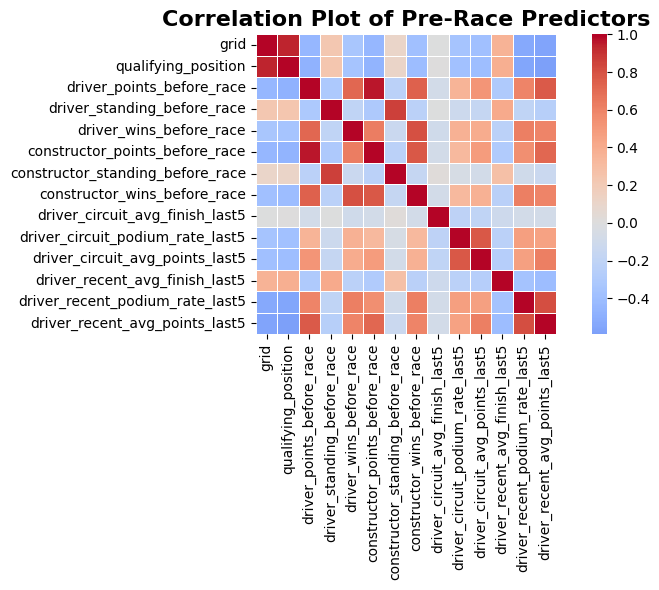

In [37]:
predictor_cols = [
    "grid",
    "qualifying_position",
    "driver_points_before_race",
    "driver_standing_before_race",
    "driver_wins_before_race",
    "constructor_points_before_race",
    "constructor_standing_before_race",
    "constructor_wins_before_race",
    "driver_circuit_avg_finish_last5",
    "driver_circuit_podium_rate_last5",
    "driver_circuit_avg_points_last5",
    "driver_recent_avg_finish_last5",
    "driver_recent_podium_rate_last5",
    "driver_recent_avg_points_last5"
]

# only keep columns that actually exist
predictor_cols = [col for col in predictor_cols if col in modeling_data.columns]

corr = modeling_data[predictor_cols].corr()

plt.figure(figsize=(9, 6))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True
)


plt.title("Correlation Plot of Pre-Race Predictors", fontsize=16, weight="bold")
plt.tight_layout()
plt.show()

## Set Up Feature Sets

In [38]:
feature_sets = {

    # very simple baseline
    "grid_only": [
        "grid"
    ],

    # strongest basic pre-race variables
    "grid_and_qualifying": [
        "grid",
        "qualifying_position"
    ],

    # race context only
    "race_context": [
        "grid",
        "qualifying_position",
        "year",
        "round",
        "circuitId"
    ],

    # driver/team/circuit identity
    "driver_constructor_circuit": [
        "grid",
        "qualifying_position",
        "driverId",
        "constructorId",
        "circuitId"
    ],

    # current season standings before the race
    "season_standings": [
        "grid",
        "qualifying_position",
        "driver_points_before_race",
        "driver_standing_before_race",
        "driver_wins_before_race",
        "constructor_points_before_race",
        "constructor_standing_before_race",
        "constructor_wins_before_race"
    ],

    # driver history at this exact circuit
    "driver_circuit_history": [
        "grid",
        "qualifying_position",
        "driver_circuit_avg_finish_last5",
        "driver_circuit_podium_rate_last5",
        "driver_circuit_avg_points_last5"
    ],

    # recent driver form, regardless of circuit/team
    "driver_recent_form": [
        "grid",
        "qualifying_position",
        "driver_recent_avg_finish_last5",
        "driver_recent_podium_rate_last5",
        "driver_recent_avg_points_last5"
    ],

    # season standings + circuit history
    "standings_and_circuit_history": [
        "grid",
        "qualifying_position",
        "driver_points_before_race",
        "driver_standing_before_race",
        "driver_wins_before_race",
        "constructor_points_before_race",
        "constructor_standing_before_race",
        "constructor_wins_before_race",
        "driver_circuit_avg_finish_last5",
        "driver_circuit_podium_rate_last5",
        "driver_circuit_avg_points_last5"
    ],

    # season standings + recent form
    "standings_and_recent_form": [
        "grid",
        "qualifying_position",
        "driver_points_before_race",
        "driver_standing_before_race",
        "driver_wins_before_race",
        "constructor_points_before_race",
        "constructor_standing_before_race",
        "constructor_wins_before_race",
        "driver_recent_avg_finish_last5",
        "driver_recent_podium_rate_last5",
        "driver_recent_avg_points_last5"
    ],

    # all engineered pre-race features
    "all_valid_features": [
        "driverId",
        "constructorId",
        "circuitId",
        "year",
        "round",
        "grid",
        "qualifying_position",
        "driver_points_before_race",
        "driver_standing_before_race",
        "driver_wins_before_race",
        "constructor_points_before_race",
        "constructor_standing_before_race",
        "constructor_wins_before_race",
        "driver_circuit_avg_finish_last5",
        "driver_circuit_podium_rate_last5",
        "driver_circuit_avg_points_last5",
        "driver_recent_avg_finish_last5",
        "driver_recent_podium_rate_last5",
        "driver_recent_avg_points_last5"
    ]
}

## Setting up Models

list and why i used them


### Train, Validation and Test sets

In [39]:
train = modeling_data[modeling_data["year"] <= 2018]

val = modeling_data[
    (modeling_data["year"] >= 2019) &
    (modeling_data["year"] <= 2021)
]

test = modeling_data[modeling_data["year"] >= 2022]

In [40]:
print("Train shape:", train.shape)
print("Validation shape:", val.shape)
print("Test shape:", test.shape)

Train shape: (7928, 26)
Validation shape: (1197, 26)
Test shape: (1359, 26)


In [41]:
models = {

    #baseline
    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000, random_state=42)
    ),

    "Elastic Net Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(
            solver="saga",
            l1_ratio=0.5,
            C=1.0,
            max_iter=5000,
            random_state=42
        )
    ),

    "LDA": make_pipeline(
        StandardScaler(),
        LinearDiscriminantAnalysis()
    ),

    "QDA": make_pipeline(
        StandardScaler(),
        QuadraticDiscriminantAnalysis(reg_param=0.1)
    ),

    "KNN": make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=15)
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

### Test loop

In [42]:
model_results = []

In [43]:

def test_model(model, model_name, feature_set_name, features):
    
    X_train = train[features]
    Y_train = train["podium"]

    X_val = val[features]
    Y_val = val["podium"]

    model.fit(X_train, Y_train)

    preds = model.predict(X_val)
    probs = model.predict_proba(X_val)[:, 1]

    result = {
        "feature_set": feature_set_name,
        "model": model_name,
        "accuracy": accuracy_score(Y_val, preds),
        "precision": precision_score(Y_val, preds, zero_division=0),
        "recall": recall_score(Y_val, preds, zero_division=0),
        "f1": f1_score(Y_val, preds, zero_division=0),
        "roc_auc": roc_auc_score(Y_val, probs)
    }

    return result

In [44]:
for feature_set_name, features in feature_sets.items():

    for model_name, model in models.items():

        result = test_model(
            model,
            model_name,
            feature_set_name,
            features
        )

        model_results.append(result)


In [46]:
results_df = pd.DataFrame(model_results)

results_df.sort_values("roc_auc", ascending=False).head()

,feature_set,model,accuracy,precision,recall,f1,roc_auc
71,standings_and_recent_form,Gradient Boosting,0.915622,0.736527,0.683333,0.708934,0.936166
79,all_valid_features,Gradient Boosting,0.914787,0.753247,0.644444,0.694611,0.934833
70,standings_and_recent_form,Random Forest,0.907268,0.741259,0.588889,0.656347,0.934071
63,standings_and_circuit_history,Gradient Boosting,0.912281,0.719298,0.683333,0.700855,0.932738
61,standings_and_circuit_history,Decision Tree,0.909774,0.706897,0.683333,0.694915,0.930386


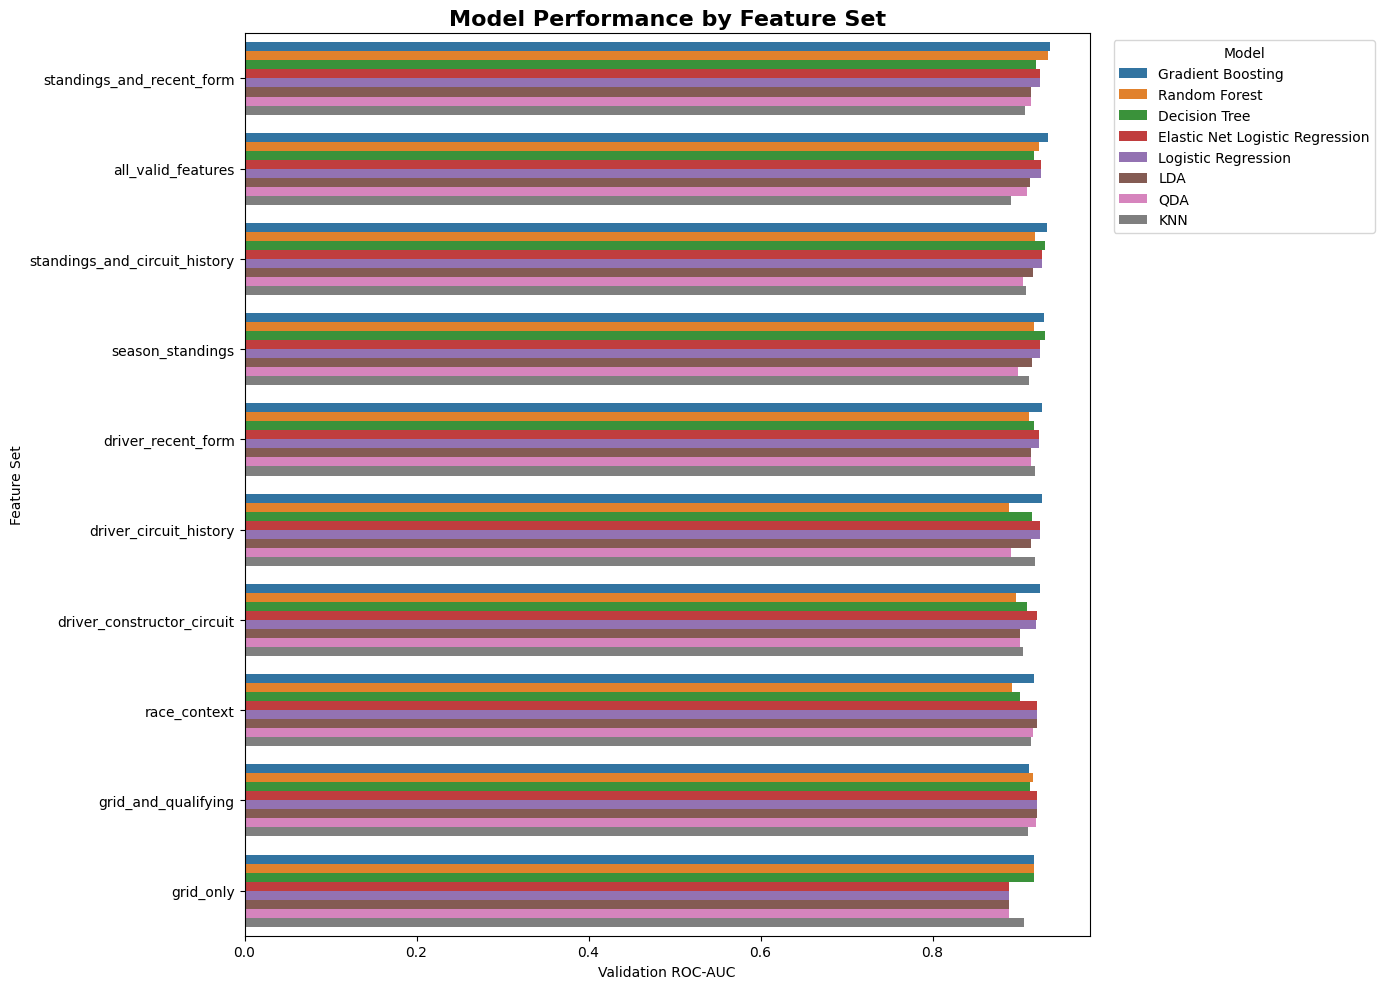

In [56]:
#make this better 

plot_df = results_df.sort_values("roc_auc", ascending=False).copy()

plt.figure(figsize=(14, 10))

sns.barplot(
    data=plot_df,
    y="feature_set",
    x="roc_auc",
    hue="model"
)

plt.title("Model Performance by Feature Set", fontsize=16, weight="bold")
plt.xlabel("Validation ROC-AUC")
plt.ylabel("Feature Set")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [57]:
results_df.to_csv("../data/processed/model_experiment_results.csv", index=False)

## Model Tuning and Selection

In [61]:
train = modeling_data[modeling_data["year"] <= 2018]

val = modeling_data[
    (modeling_data["year"] >= 2019) &
    (modeling_data["year"] <= 2021)
]

test = modeling_data[modeling_data["year"] >= 2022]

#define the best features based on best model + feature performance
best_features = [
    "grid",
    "qualifying_position",
    "driver_points_before_race",
    "driver_standing_before_race",
    "driver_wins_before_race",
    "constructor_points_before_race",
    "constructor_standing_before_race",
    "constructor_wins_before_race",
    "driver_recent_avg_finish_last5",
    "driver_recent_podium_rate_last5",
    "driver_recent_avg_points_last5"
]

X_train = train[best_features]
Y_train = train["podium"]

X_val = val[best_features]
Y_val = val["podium"]

X_test = test[best_features]
Y_test = test["podium"]


In [62]:
tuning_results = []
n_estimators_list = [50, 100, 200]
learning_rate_list = [0.01, 0.05, 0.1]
max_depth_list = [1, 2, 3]

In [66]:
for n in n_estimators_list:
    
    for rate in learning_rate_list:
        
        for depth in max_depth_list:
            
            model = GradientBoostingClassifier(
                n_estimators=n,
                learning_rate=rate,
                max_depth=depth,
                random_state=42
            )
            
            model.fit(X_train, Y_train)
            
            val_preds = model.predict(X_val)
            val_probs = model.predict_proba(X_val)[:, 1]
            
            tuning_results.append({
                "n_estimators": n,
                "learning_rate": rate,
                "max_depth": depth,
                "accuracy": accuracy_score(Y_val, val_preds),
                "precision": precision_score(Y_val, val_preds, zero_division=0),
                "recall": recall_score(Y_val, val_preds, zero_division=0),
                "f1": f1_score(Y_val, val_preds, zero_division=0),
                "roc_auc": roc_auc_score(Y_val, val_probs)
            })

In [68]:
tuning_df = pd.DataFrame(tuning_results)

tuning_df.sort_values("roc_auc", ascending=False).head()

,n_estimators,learning_rate,max_depth,accuracy,precision,recall,f1,roc_auc
44,100,0.10,3,0.915622,0.736527,0.683333,0.708934,0.936166
17,100,0.10,3,0.915622,0.736527,0.683333,0.708934,0.936166
22,200,0.05,2,0.913952,0.730539,0.677778,0.703170,0.935835
49,200,0.05,2,0.913952,0.730539,0.677778,0.703170,0.935835
8,50,0.10,3,0.916458,0.735294,0.694444,0.714286,0.935469


## Run on Training Set



In [72]:
best_row = tuning_df.sort_values("roc_auc", ascending=False).iloc[0]

best_n_estimators = int(best_row["n_estimators"])
best_learning_rate = best_row["learning_rate"]
best_max_depth = int(best_row["max_depth"])

In [73]:
train_val = pd.concat([train, val])

X_train_val = train_val[best_features]
Y_train_val = train_val["podium"]

final_model = GradientBoostingClassifier(
    n_estimators=best_n_estimators,
    learning_rate=best_learning_rate,
    max_depth=best_max_depth,
    random_state=42
)

final_model.fit(X_train_val, Y_train_val)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",np.float64(0.1)
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N`

In [74]:
test_preds = final_model.predict(X_test)
test_probs = final_model.predict_proba(X_test)[:, 1]

In [75]:
test_accuracy = accuracy_score(Y_test, test_preds)
test_precision = precision_score(Y_test, test_preds, zero_division=0)
test_recall = recall_score(Y_test, test_preds, zero_division=0)
test_f1 = f1_score(Y_test, test_preds, zero_division=0)
test_auc = roc_auc_score(Y_test, test_probs)

print("Final Test Results")
print("Accuracy:", test_accuracy)
print("Precision:", test_precision)
print("Recall:", test_recall)
print("F1 Score:", test_f1)
print("ROC-AUC:", test_auc)

Final Test Results
Accuracy: 0.8984547461368654
Precision: 0.6774193548387096
Recall: 0.6176470588235294
F1 Score: 0.6461538461538462
ROC-AUC: 0.9337556234615059


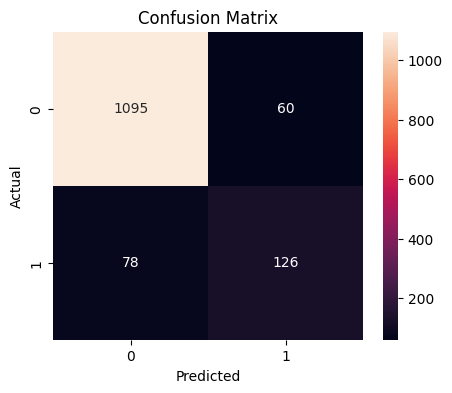

In [78]:
cm = confusion_matrix(Y_test, test_preds)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

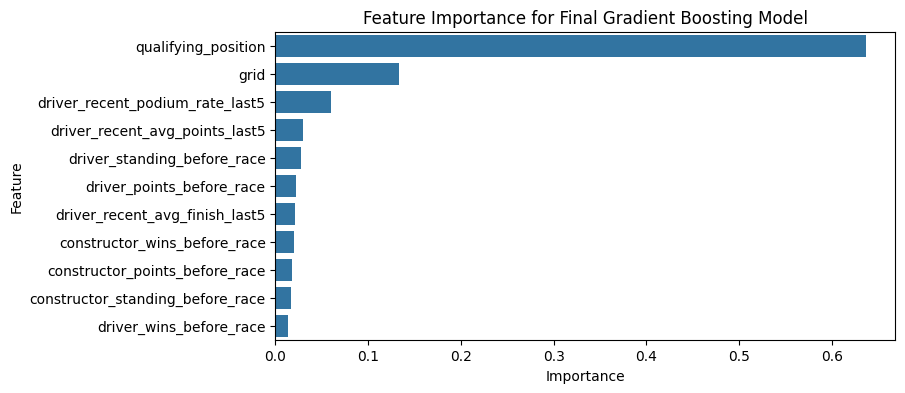

In [79]:
importance_df = pd.DataFrame({
    "feature": best_features,
    "importance": final_model.feature_importances_
})

importance_df = importance_df.sort_values("importance", ascending=False)

plt.figure(figsize=(8,4))

sns.barplot(
    data=importance_df,
    x="importance",
    y="feature"
)

plt.title("Feature Importance for Final Gradient Boosting Model")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

### Race-level podium prediction

In [80]:
test_with_preds = test.copy()

test_with_preds["podium_probability"] = test_probs
test_with_preds["predicted_podium"] = test_preds

In [81]:
predicted_top3 = (
    test_with_preds
    .sort_values(["raceId", "podium_probability"], ascending=[True, False])
    .groupby("raceId")
    .head(3)
)

predicted_top3.head()

,raceId,driverId,forename,surname,constructorId,constructor_name,circuitId,circuit_name,year,round,grid,qualifying_position,driver_points_before_race,driver_standing_before_race,driver_wins_before_race,constructor_points_before_race,constructor_standing_before_race,constructor_wins_before_race,driver_circuit_avg_finish_last5,driver_circuit_podium_rate_last5,driver_circuit_avg_points_last5,driver_recent_avg_finish_last5,driver_recent_podium_rate_last5,driver_recent_avg_points_last5,positionOrder,podium,podium_probability,predicted_podium
25407,1074,830,Max,Verstappen,9,Red Bull,3,Bahrain International Circuit,2022,1,2,2.0,0.0,99.0,0.0,0.0,99.0,0.0,9.2,0.4,9.8,1.6,1.0,21.2,19,0,0.771689,1
25412,1074,844,Charles,Leclerc,6,Ferrari,3,Bahrain International Circuit,2022,1,1,1.0,0.0,99.0,0.0,0.0,99.0,0.0,10.2,0.2,5.0,7.0,0.0,6.2,1,1,0.582044,1
25400,1074,1,Lewis,Hamilton,131,Mercedes,3,Bahrain International Circuit,2022,1,5,5.0,0.0,99.0,0.0,0.0,99.0,0.0,1.6,1.0,21.6,1.4,1.0,22.4,3,1,0.547997,1
25432,1075,844,Charles,Leclerc,6,Ferrari,77,Jeddah Corniche Circuit,2022,2,2,2.0,26.0,1.0,1.0,44.0,1.0,1.0,7.0,0.0,6.0,6.2,0.2,9.4,2,1,0.733327,1
25428,1075,832,Carlos,Sainz,6,Ferrari,77,Jeddah Corniche Circuit,2022,2,3,3.0,18.0,2.0,0.0,44.0,1.0,1.0,8.0,0.0,4.0,5.2,0.4,10.2,3,1,0.699636,1


In [82]:
race_scores = (
    predicted_top3
    .groupby("raceId")["podium"]
    .sum()
    .reset_index()
)

race_scores = race_scores.rename(columns={"podium": "actual_podiums_found"})

race_scores.head()

,raceId,actual_podiums_found
0,1074,2
1,1075,3
2,1076,2
3,1077,1
4,1078,3


In [83]:
race_scores["actual_podiums_found"].mean()

np.float64(1.911764705882353)

In [84]:
final_results = pd.DataFrame([{
    "model": "Tuned Gradient Boosting",
    "feature_set": "standings_and_recent_form",
    "accuracy": test_accuracy,
    "precision": test_precision,
    "recall": test_recall,
    "f1": test_f1,
    "roc_auc": test_auc,
    "avg_actual_podiums_found_per_race": race_scores["actual_podiums_found"].mean()
}])

final_results

,model,feature_set,accuracy,precision,recall,f1,roc_auc,avg_actual_podiums_found_per_race
0,Tuned Gradient Boosting,driver_history,0.898455,0.677419,0.617647,0.646154,0.933756,1.911765


### Predict for One race

In [86]:
race_id = 1075

specific_race = test_with_preds[test_with_preds["raceId"] == race_id].copy()

specific_race_predictions = specific_race.sort_values(
    "podium_probability",
    ascending=False
)

specific_race_predictions[[
    "raceId",
    "year",
    "round",
    "forename",
    "surname",
    "constructor_name",
    "grid",
    "qualifying_position",
    "podium_probability",
    "predicted_podium",
    "podium",
]].head(10)

,raceId,year,round,forename,surname,constructor_name,grid,qualifying_position,podium_probability,predicted_podium,podium
25432,1075,2022,2,Charles,Leclerc,Ferrari,2,2.0,0.733327,1,1
25428,1075,2022,2,Carlos,Sainz,Ferrari,3,3.0,0.699636,1,1
25427,1075,2022,2,Max,Verstappen,Red Bull,4,4.0,0.621528,1,1
25423,1075,2022,2,Sergio,Pérez,Red Bull,1,1.0,0.519555,1,0
25434,1075,2022,2,George,Russell,Mercedes,6,6.0,0.108117,0,0
25425,1075,2022,2,Valtteri,Bottas,Alfa Romeo,8,8.0,0.102130,0,0
25420,1075,2022,2,Lewis,Hamilton,Mercedes,15,16.0,0.089574,0,0
25429,1075,2022,2,Esteban,Ocon,Alpine F1 Team,5,5.0,0.079164,0,0
25421,1075,2022,2,Fernando,Alonso,Alpine F1 Team,7,7.0,0.055896,0,0
25426,1075,2022,2,Kevin,Magnussen,Haas F1 Team,10,10.0,0.049599,0,0


In [89]:
predicted_podium = specific_race_predictions.head(3)[[
    "forename",
    "surname",
    "podium_probability",
    "positionOrder"
]]

actual_podium = specific_race_predictions[
    specific_race_predictions["podium"] == 1
][[
    "forename",
    "surname",
    "constructor_name",
    "podium_probability",
    "positionOrder"
]].sort_values("positionOrder")

print("Predicted Podium:")
display(predicted_podium)

print("Actual Podium:")
display(actual_podium)

Predicted Podium:


,forename,surname,podium_probability,positionOrder
25432,Charles,Leclerc,0.733327,2
25428,Carlos,Sainz,0.699636,3
25427,Max,Verstappen,0.621528,1


Actual Podium:


,forename,surname,constructor_name,podium_probability,positionOrder
25427,Max,Verstappen,Red Bull,0.621528,1
25432,Charles,Leclerc,Ferrari,0.733327,2
25428,Carlos,Sainz,Ferrari,0.699636,3


LOOKS RIGHT

### Row level podiuma accuracy

In [91]:
(test_with_preds["predicted_podium"] == test_with_preds["podium"]).mean()

np.float64(0.8984547461368654)